In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


df = pd.read_csv('merged_dataset.csv')

df_alliances = pd.read_csv('alliances.csv')

In [2]:
#target specific alliances

alliances = [
    'Lublin Triangle', 'European Union', 
    'North Atlantic Treaty Organization (NATO)',
    'Collective Security Treaty Organization (CSTO)',
    'Union State'
]

df_alliances = df_alliances[df_alliances['name'].isin(alliances)]

#split individual members of alliances
df_alliances['members'] = df_alliances['members'].apply(
    lambda x: x if isinstance(x, list) else [m.strip() for m in str(x).split(',')]
)

# explode to one row per country–alliance
exp = df_alliances.explode('members').rename(columns={'members': 'Country Name'})

#convert df to wide format
df_alliances = (
    pd.crosstab(exp['Country Name'], exp['name'])
      .reset_index()
)

df_alliances.to_csv('df_alliances.csv', index=False)

df_alliances.head()


name,Country Name,Collective Security Treaty Organization (CSTO),European Union,Lublin Triangle,North Atlantic Treaty Organization (NATO),Union State
0,Albania,0,0,0,1,0
1,Armenia,1,0,0,0,0
2,Austria,0,1,0,0,0
3,Belarus,1,0,0,0,1
4,Belgium,0,1,0,1,0


In [3]:
#merge datasets

df = df.merge(df_alliances, on='Country Name', how='left').fillna(0)

df.head()

,Country Name,aid_type_general,aid_type_specific,reporting_currency,measure,source_reported_value,tot_activity_value,tot_activity_value_EUR,tot_activity_value_constant_currency,tot_sub_activity_value,...,"Armed forces personnel, total",Arms exports (SIPRI trend indicator values),Arms imports (SIPRI trend indicator values),Military expenditure (% of GDP),Military expenditure (current USD),Collective Security Treaty Organization (CSTO),European Union,Lublin Triangle,North Atlantic Treaty Organization (NATO),Union State
0,Australia,Humanitarian,Equipment,AUD,Allocation,35000000,35000000,23417159.978473667,2.117815e+07,35000000,...,0.0,19000000.0,815000000.0,1.908336,3.244533e+10,0.0,0.0,0.0,0.0,0.0
1,Australia,Humanitarian,Equipment,AUD,Allocation,32600000,32600000,21811411.865664043,1.972593e+07,32600000,...,0.0,19000000.0,815000000.0,1.908336,3.244533e+10,0.0,0.0,0.0,0.0,0.0
2,Australia,Humanitarian,Assistance,AUD,Allocation,12000000,12000000,8028740.564048114,7.261080e+06,12000000,...,0.0,19000000.0,815000000.0,1.908336,3.244533e+10,0.0,0.0,0.0,0.0,0.0
3,Australia,Humanitarian,Contribution,AUD,Allocation,10000000,10000000,6690617.136706762,6.050900e+06,10000000,...,0.0,19000000.0,815000000.0,1.908336,3.244533e+10,0.0,0.0,0.0,0.0,0.0
4,Australia,Humanitarian,Contribution,AUD,Allocation,8000000,8000000,5352493.70936541,4.840720e+06,8000000,...,0.0,19000000.0,815000000.0,1.908336,3.244533e+10,0.0,0.0,0.0,0.0,0.0


In [ ]:
#created lagged effect
df = df.sort_values(['Country Name', 'Year'])
for col in [
    'tot_activity_value_EUR','tot_sub_activity_value_EUR',
    'tot_value_deliv_EUR','Armed forces personnel, total',
    'Arms exports (SIPRI trend indicator values)',
    'Arms imports (SIPRI trend indicator values)',
    'Military expenditure (% of GDP)',
    'Military expenditure (current USD)'
]:
    df['lag_' + col] = df.groupby('Country Name')[col].shift(1)

#drop rows with null values
df = df.dropna()

df.columns

Index(['Country Name', 'aid_type_general', 'aid_type_specific',
       'reporting_currency', 'measure', 'source_reported_value',
       'tot_activity_value', 'tot_activity_value_EUR',
       'tot_activity_value_constant_currency', 'tot_sub_activity_value',
       'tot_sub_activity_value_EUR',
       'tot_sub_activity_value_constant_currency',
       'tot_sub_activity_value_constant_currency_redistr',
       'tot_sub_activity_value_EUR_redistr', 'tot_value_deliv_EUR', 'Year',
       'Country Code', 'Armed forces personnel, total',
       'Arms exports (SIPRI trend indicator values)',
       'Arms imports (SIPRI trend indicator values)',
       'Military expenditure (% of GDP)', 'Military expenditure (current USD)',
       'Collective Security Treaty Organization (CSTO)', 'European Union',
       'Lublin Triangle', 'North Atlantic Treaty Organization (NATO)',
       'Union State', 'lag_tot_activity_value_EUR',
       'lag_tot_sub_activity_value_EUR', 'lag_tot_value_deliv_EUR',
       'la

In [5]:
#split into train and test splits
train = df[df['Year'] == 2022]
test = df[df['Year'] == 2023]

#define predictors + target variables
num_columns = [
    'lag_tot_activity_value_EUR', 'lag_tot_sub_activity_value_EUR',
    'lag_tot_value_deliv_EUR', 'lag_Armed forces personnel, total',
    'lag_Arms exports (SIPRI trend indicator values)',
    'lag_Arms imports (SIPRI trend indicator values)',
    'lag_Military expenditure (% of GDP)',
    'lag_Military expenditure (current USD)'
]

alliances_features = [
    'Lublin Triangle', 'European Union',
    'Union State', 'North Atlantic Treaty Organization (NATO)',
    'Collective Security Treaty Organization (CSTO)'
]

def clean_numeric(df):
    df = df.copy()
    df[num_columns] = df[num_columns].replace({'.': np.nan, '': np.nan})
    df[num_columns] = df[num_columns].replace({',': ''}, regex=True)
    df[num_columns] = df[num_columns].apply(pd.to_numeric, errors='coerce')
    return df

train = clean_numeric(train)
test = clean_numeric(test)

X_train = train[num_columns + alliances_features].copy()
y_train = train['aid_type_general'].astype('category')

X_test = test[num_columns + alliances_features].copy()
y_test = test['aid_type_general'].astype('category')

In [6]:
#impute missing values
imputer = SimpleImputer(strategy='median')
X_train[num_columns] = imputer.fit_transform(X_train[num_columns])
X_test[num_columns] = imputer.transform(X_test[num_columns])


In [7]:
#standardize numeric predictor variables
scaler = StandardScaler()
X_train[num_columns] = scaler.fit_transform(X_train[num_columns])
X_test[num_columns] = scaler.transform(X_test[num_columns])

In [8]:
#train multionomial logistic regression model
model = LogisticRegression(
    multi_class='multinomial',
    max_iter=500,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500,
                   multi_class='multinomial')

In [9]:
#predict on the model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [10]:
#evaluate results
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

   Financial       0.19      0.36      0.25        98
Humanitarian       0.31      0.69      0.43       277
    Military       0.90      0.53      0.67      1011

    accuracy                           0.55      1386
   macro avg       0.47      0.52      0.45      1386
weighted avg       0.73      0.55      0.59      1386

[[ 35  48  15]
 [ 43 191  43]
 [104 373 534]]


In [11]:
#roc and auc
y_test_bin = label_binarize(y_test, classes=model.classes_)

#calculate tpr and fpr for each aid type
fpr_financial, tpr_financial, thresh_financial = roc_curve(y_test_bin[:,0], y_proba[:,0])
acu_financial = auc(fpr_financial, tpr_financial)

fpr_humanitarian, tpr_humanitarian, thresh_humanitarian = roc_curve(y_test_bin[:,1], y_proba[:,1])
acu_humanitarain = auc(fpr_humanitarian, tpr_humanitarian)

fpr_military, tpr_military, thresh_military = roc_curve(y_test_bin[:,2], y_proba[:,2])
acu_military = auc(fpr_military, tpr_military)


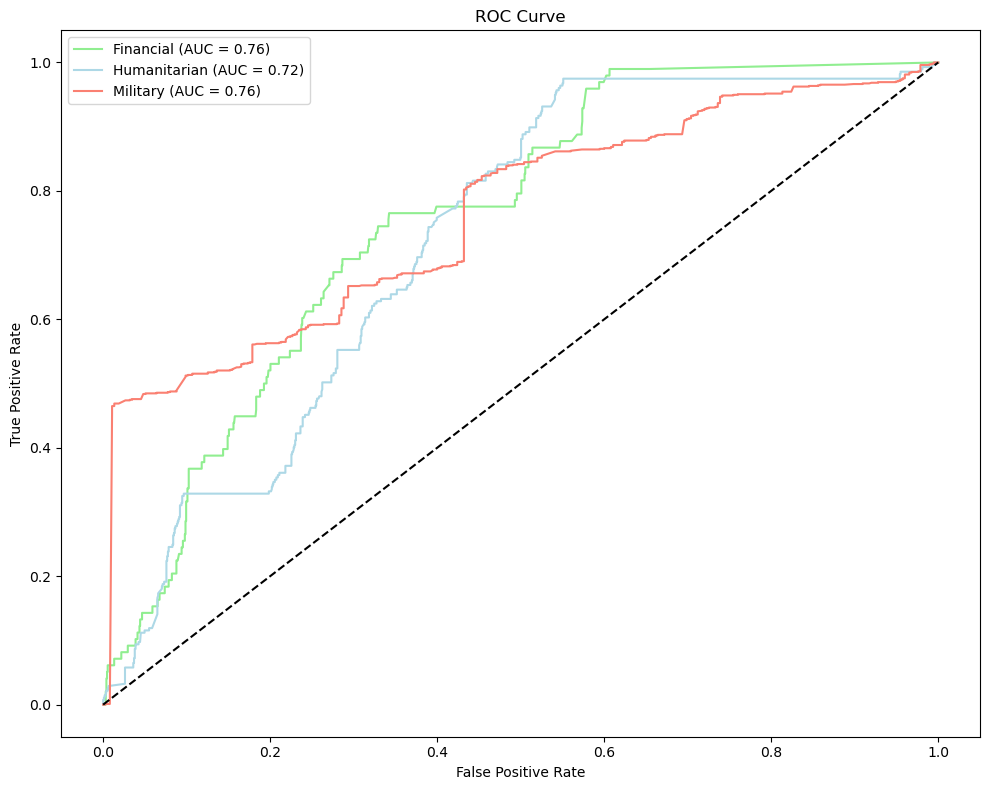

In [12]:
#plot roc curve
plt.figure(figsize=(10,8))

plt.plot(fpr_financial, tpr_financial, color='lightgreen', label=f'Financial (AUC = {acu_financial:.2f})')
plt.plot(fpr_humanitarian, tpr_humanitarian, color='lightblue', label=f'Humanitarian (AUC = {acu_humanitarain:.2f})')
plt.plot(fpr_military, tpr_military, color='salmon', label=f'Military (AUC = {acu_military:.2f})')

plt.plot([0,1], [0,1], 'k--')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.tight_layout()
plt.legend()


In [13]:
#create coefficient data frame
coef_df = pd.DataFrame(
    model.coef_.T,
    index=X_train.columns,
    columns=model.classes_
)


#compute feature importance
feature_importance = coef_df.abs().mean(axis=1)

rename = {
    'lag_tot_activity_value_EUR': 'Activity Value (EUR)',
    'lag_tot_sub_activity_value_EUR': 'Sub-Activity Value (EUR)',
    'lag_tot_value_deliv_EUR': 'Delivered Value (EUR)',
    'lag_Armed forces personnel, total': 'Armed Forces (Total)',
    'lag_Arms exports (SIPRI trend indicator values)': 'Arms Exports',
    'lag_Arms imports (SIPRI trend indicator values)': 'Arms Imports',
    'lag_Military expenditure (% of GDP)': 'Military Expenditure (% GDP)',
    'lag_Military expenditure (current USD)': 'Military Expenditure (USD)'
}



#split top numeric and alliances features
top_num = feature_importance[num_columns].sort_values(ascending=True)

#replace column names
top_num.index = top_num.index.map(lambda x: rename.get(x, x))

alliance_coeffs = feature_importance[alliances_features].sort_values(ascending=True)

#drop zero coefficients
top_num = top_num[top_num != 0]

alliance_coeffs = alliance_coeffs[alliance_coeffs != 0]

Text(0.5, 0, 'Average Coefficient Magnitude')

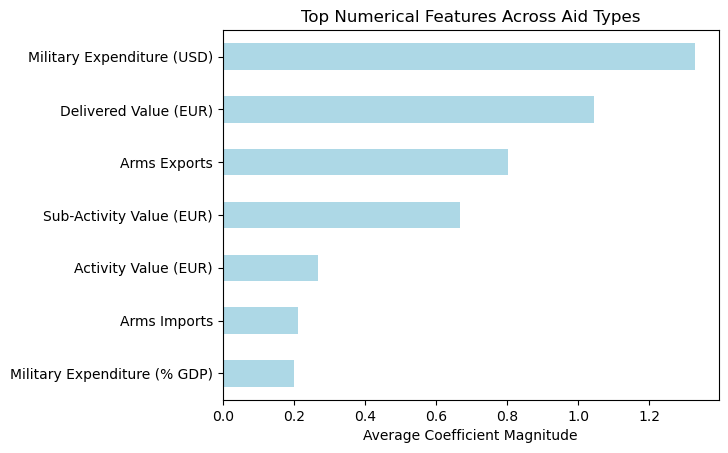

In [14]:
#top numeric features graph
top_num.plot(kind='barh', color='lightblue')

plt.title('Top Numerical Features Across Aid Types')
plt.xlabel('Average Coefficient Magnitude')


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Predictors')

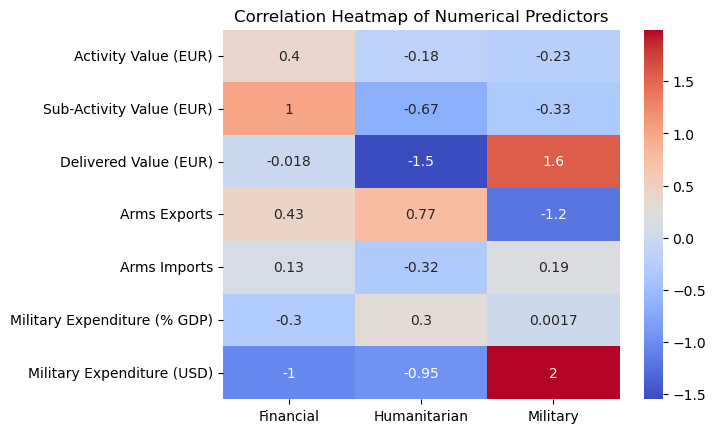

In [15]:
#select only numeric predictors
num_pred = coef_df.loc[num_columns]

#drop zero coefficients
num_pred = num_pred[(num_pred != 0).any(axis=1)]

#rename columns
num_pred.index = num_pred.index.map(lambda x: rename.get(x, x))

sns.heatmap(num_pred, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Predictors')

Text(0.5, 0, 'Average Coefficient Magnitude')

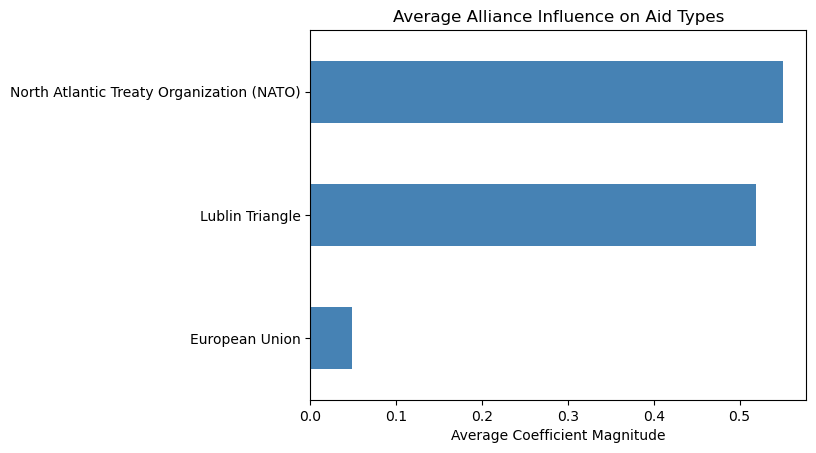

In [16]:
#alliance coefficient graph

alliance_coeffs.plot(kind='barh', color='steelblue')

plt.title('Average Alliance Influence on Aid Types')
plt.xlabel('Average Coefficient Magnitude')



Text(0.5, 1.0, 'Correlation Heatmap of Alliance Predictors')

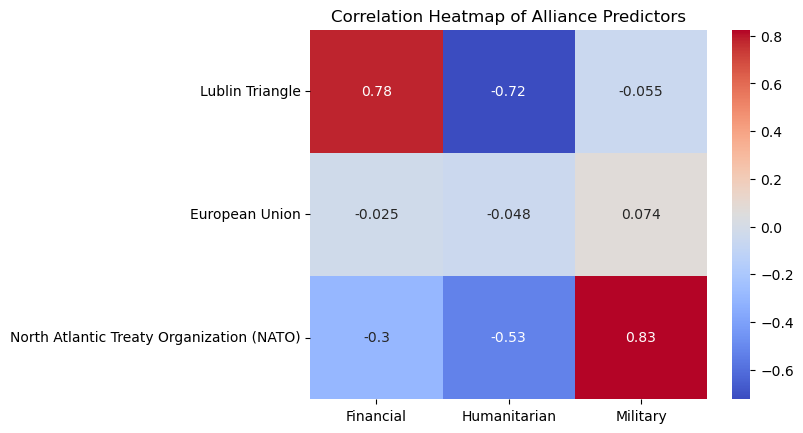

In [17]:
#select only alliance predictors
alliance_pred = coef_df.loc[alliances_features]

alliance_pred = alliance_pred[(alliance_pred != 0).any(axis=1)]

sns.heatmap(alliance_pred, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Alliance Predictors')